In [66]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [67]:
data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [68]:
x=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target)
x,y

(       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude  
 0    

In [69]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']
x = x[features]

print("Enter property details to predict median house price:")

MedInc = float(input("Median Income (in $10,000s): "))
HouseAge = float(input("House Age (years): "))
AveRooms = float(input("Average Rooms: "))
Population = float(input("Population: "))

user_input = pd.DataFrame(
    [[MedInc, HouseAge, AveRooms, Population]],
    columns=features
)

print(user_input)

Enter property details to predict median house price:
Median Income (in $10,000s): 10000
House Age (years): 6
Average Rooms: 5
Population: 3
    MedInc  HouseAge  AveRooms  Population
0  10000.0       6.0       5.0         3.0


In [70]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((4128, 4), (16512, 4), (4128,), (16512,))

In [71]:
.scaler=StandardScaler()
x_scaled_train=scaler.fit_transform(x_train)
x_scaled_test=scaler.fit_transform(x_test)
x_scaled_train,x_scaled_test

(array([[-0.96331319,  0.35280325, -0.00675899, -0.64859415],
        [-0.73060234, -0.20424843, -0.35879104, -0.02032072],
        [-0.80991421,  1.54648542, -0.35522251, -0.36599398],
        ...,
        [-0.48963637,  0.59153969, -0.47705592,  0.25900293],
        [ 0.96535505, -1.07961535,  0.29278709,  0.27620468],
        [-0.67715304,  1.86480067, -0.66375807,  0.96591294]]),
 array([[-1.15453971, -0.29052552, -0.53667676, -0.02695064],
        [-0.7062249 ,  0.10661646, -0.16528795,  0.12901574],
        [-0.20585896,  1.85404119, -0.63094873, -0.10087691],
        ...,
        [ 0.30726928, -1.0053811 ,  0.21260725, -0.77793327],
        [ 0.06831922, -1.0053811 , -0.33643664,  0.17769888],
        [ 0.14035757, -1.48195148, -0.45264542,  0.14344037]]))

In [72]:
model=LinearRegression()
model.fit(x_scaled_train,y_train)
user_scaled = scaler.transform(user_input)

In [73]:
predicted_price = model.predict(user_scaled)[0]
predicted_price_dollars = predicted_price * 100000

print(f"\nPredicted Median House Price: ${predicted_price_dollars:,.2f}")


Predicted Median House Price: $432,405,320.41


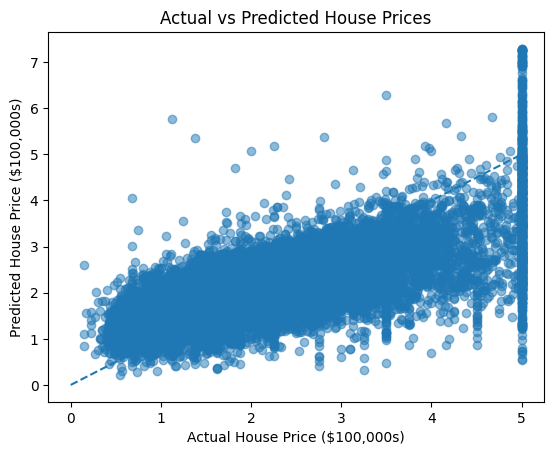

In [74]:
x_test_income = x_test['MedInc']
y_test_pred = model.predict(x_scaled_test)

sorted_idx = x_test_income.argsort()

plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([0, 5], [0, 5], linestyle="--")
plt.xlabel("Actual House Price ($100,000s)")
plt.ylabel("Predicted House Price ($100,000s)")
plt.title("Actual vs Predicted House Prices")
plt.show()



In [75]:
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)

print("Model Evaluation:")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.3f}  (~${mae*100000:,.0f})")

Model Evaluation:
R² Score : 0.514
MAE      : 0.601  (~$60,130)
